In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from sklearn import preprocessing , model_selection 

from sklearn import datasets

In [2]:
digit = datasets.load_digits()

In [3]:
digit.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
i = 12

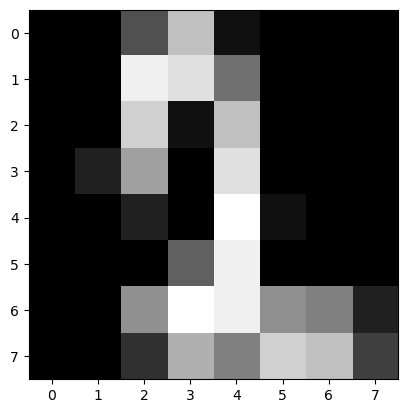

In [ ]:
plt.imshow(digit['data'][i].reshape(8,8), cmap='gray')

In [ ]:
digit['target'][i]

np.int64(2)

In [7]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(digit['data'], digit['target'],random_state= 7 , test_size= 0.2)

In [10]:
print(X_train.shape)
print(y_train.shape)

(1437, 64)
(1437,)


In [11]:
y_train_cat =keras.utils.to_categorical(y_train)
y_test_cat = keras.utils.to_categorical(y_test)

In [12]:
X_train.shape

(1437, 64)

In [15]:
scaler = preprocessing.MinMaxScaler()

x_train_scaled = scaler.fit_transform(X_train.astype('float32'))
x_test_scaled = scaler.transform(X_test.astype('float32'))

In [16]:
model =Sequential()
model.add(Dense(50,activation='relu', input_dim = 64))
model.add(Dense(10,activation='softmax'))

c:\Users\r.navabian\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,760 (14.69 KB)

 Trainable params: 3,760 (14.69 KB)

 Non-trainable params: 0 (0.00 B)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9667 - loss: 0.1014 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
predicted:
[6 0 5 9 2 9 0 4 1 0]
True Label:
[6 0 5 9 2 9 0 4 1 0]


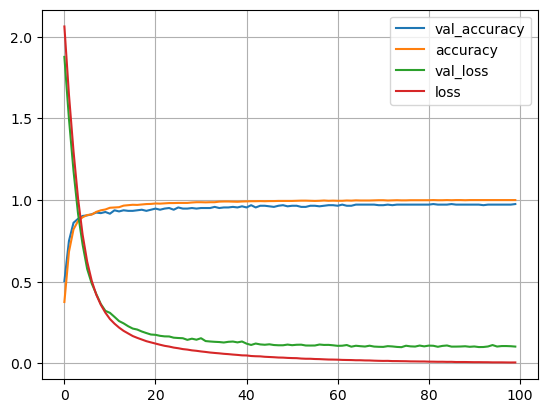

In [18]:
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

hist = model.fit(
    x_train_scaled, y_train_cat, epochs=100, batch_size=32, validation_split=0.2, verbose=0
)

plt.plot(hist.history["val_accuracy"])
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_loss"])
plt.plot(hist.history["loss"])

plt.legend(["val_accuracy", "accuracy", "val_loss", "loss"])

plt.grid(True)

model.evaluate(x_test_scaled,y_test_cat)
pred =model.predict(x_test_scaled[:10])
predicted = np.argmax(pred,axis=1)

print("predicted:")
print(predicted)
print("True Label:")
print(y_test[:10])

<h1>SGD</h1>

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9111 - loss: 0.3780 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9111 - loss: 0.3780 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9111 - loss: 0.3780 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
predicted:
[6 0 5 9 2 9 0 4 1 0]
True Label:
[6 0 5 9 2 9 0 4 1 0]


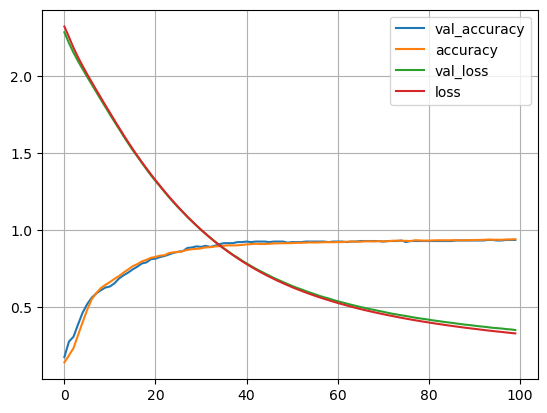

In [19]:
model_sgd =Sequential()
model_sgd.add(Dense(50,activation='relu', input_dim = 64))
model_sgd.add(Dense(10,activation='softmax'))
model_sgd.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),   
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hitst_sgd =model_sgd.fit(x_train_scaled, y_train_cat,batch_size=64 ,epochs= 100,validation_split=0.2 , verbose=0)

plt.plot(hitst_sgd.history['val_accuracy'])
plt.plot(hitst_sgd.history['accuracy'])

plt.plot(hitst_sgd.history['val_loss'])
plt.plot(hitst_sgd.history['loss'])

plt.grid(True)
plt.legend(['val_accuracy','accuracy',"val_loss", "loss"])

model_sgd.evaluate(x_test_scaled,y_test_cat)

model_sgd.evaluate(x_test_scaled,y_test_cat)


model_sgd.evaluate(x_test_scaled, y_test_cat)

pred_sgd = model_sgd.predict(x_test_scaled[:10])

predicted = np.argmax(pred_sgd, axis=1)

print("predicted:")
print(predicted)
print("True Label:")
print(y_test[:10])

RMS

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9694 - loss: 0.0995 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9694 - loss: 0.0995 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
predicted:
[6 0 5 9 2 9 0 4 1 0]
True Label:
[6 0 5 9 2 9 0 4 1 0]


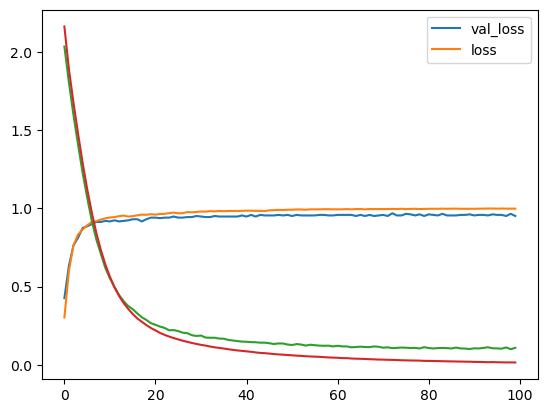

In [20]:
model_rmsprop = Sequential()
model_rmsprop.add(Dense(50, activation='relu', input_dim=64))
model_rmsprop.add(Dense(10, activation='softmax'))

model_rmsprop.compile(
    optimizer=RMSprop(learning_rate=0.001, rho=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hitst_rmsprop =model_rmsprop.fit(x_train_scaled, y_train_cat,batch_size=64 ,epochs= 100,validation_split=0.2,verbose = 0 )

plt.plot(hitst_rmsprop.history['val_accuracy'])
plt.plot(hitst_rmsprop.history['accuracy'])
plt.legend(['val_accuracy','accuracy'])

plt.plot(hitst_rmsprop.history['val_loss'])
plt.plot(hitst_rmsprop.history['loss'])


plt.legend(["val_loss", "loss"])

model_rmsprop.evaluate(x_test_scaled,y_test_cat)


model_rmsprop.evaluate(x_test_scaled, y_test_cat)

pred_rmsprop = model_rmsprop.predict(x_test_scaled[:10])

predicted = np.argmax(pred_rmsprop, axis=1)

print("predicted:")
print(predicted)
print("True Label:")
print(y_test[:10])

ADAM

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9667 - loss: 0.1232 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
predicted:
[6 0 5 9 2 9 0 4 1 0]
True Label:
[6 0 5 9 2 9 0 4 1 0]


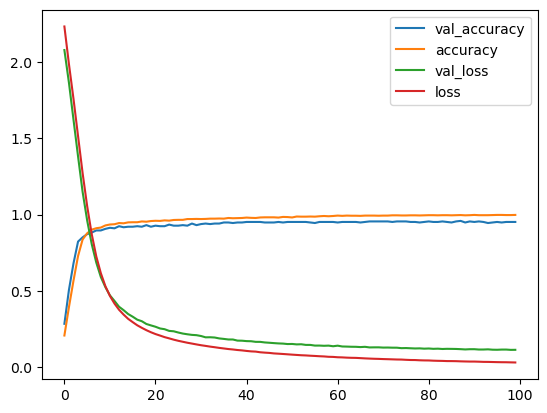

In [21]:
model_adam = Sequential()
model_adam.add(Dense(50, activation="relu", input_dim=64))
model_adam.add(Dense(10, activation="softmax"))

model_adam.compile(
    optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

hitst_adam = model_adam.fit(
    x_train_scaled,
    y_train_cat,
    batch_size=64,
    epochs=100,
    validation_split=0.2,
    verbose=0,
)

plt.plot(hitst_adam.history["val_accuracy"])
plt.plot(hitst_adam.history["accuracy"])

plt.plot(hitst_adam.history["val_loss"])
plt.plot(hitst_adam.history["loss"])

plt.legend(["val_accuracy", "accuracy" ,"val_loss", "loss"])

model_adam.evaluate(x_test_scaled, y_test_cat)

pred_adam = model_adam.predict(x_test_scaled[:10])

predicted = np.argmax(pred_adam, axis=1)

print("predicted:")
print(predicted)
print("True Label:")
print(y_test[:10])